::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`02_distribution_fitting.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/02_distribution_fitting.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`bestfitpy`, whose compiled core is a validated C++ port of the same library, so the
numbers below reproduce the upstream outputs exactly. The R version of this example
uses the same core and prints the same numbers.

## What you'll learn

- Fitting a distribution by Method of Moments (MOM), Maximum Likelihood (MLE), and
  L-moments.
- Comparing fitted distributions with log-likelihood, AIC, BIC, and RMSE.
- Visual checks: empirical vs fitted CDFs and Weibull plotting positions.
- Ranking many candidate families at once with `fit_distributions`.

## Set up

The upstream setup cell loads the CoreCLR runtime, resolves `Numerics.dll`, and
imports the .NET types. Here the setup is four ordinary imports.

In [1]:
import bestfitpy as bf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Helper function

The function below plots a histogram of the data with the PDF of a fitted
distribution, the same helper the upstream notebook defines.

In [2]:
def plot_empirical_vs_model(data, dist, title="Empirical vs fitted distribution"):
    """Plot a histogram of the data with the PDF of the fitted distribution."""
    x = np.linspace(min(data), max(data), 500)
    pdf = [dist.pdf(xi) for xi in x]
    plt.hist(data, bins=20, density=True, color="#6b7f3f", edgecolor="white",
             label="Empirical")
    plt.plot(x, pdf, color="#b06a3b", linewidth=2, label="Fitted PDF")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()

## Example data: flood peaks

We simulate 100 annual peak flows from a LogNormal distribution. As in the C#
library, `LogNormal` is the base-10 family: its parameters are the mean and
standard deviation of $\log_{10}(x)$, so `LogNormal(8, 0.5)` produces values around
$10^8$. (The base-e family is `LnNormal`.) The draw is seeded, and the port keeps
the C# Mersenne Twister bit-exact, so these are the same 100 numbers the upstream
notebook generates.

Sample size: 100
Sample mean: 158155878.08
Sample std:  213541263.95


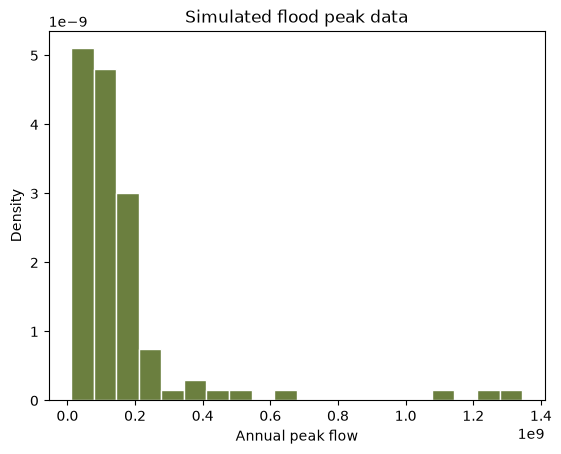

In [3]:
lognormal = bf.Distribution("LogNormal", [8, 0.5])
data = lognormal.random(100, seed=123)
print(f"Sample size: {len(data)}")
print(f"Sample mean: {np.mean(data):.2f}")
print(f"Sample std:  {np.std(data):.2f}")

plt.hist(data, bins=20, density=True, color="#6b7f3f", edgecolor="white")
plt.xlabel("Annual peak flow")
plt.ylabel("Density")
plt.title("Simulated flood peak data")
plt.show()

## Method of Moments (MOM)

The Method of Moments is the oldest and simplest approach to parameter estimation.
The idea: equate sample moments to the corresponding theoretical moments of the
distribution and solve for the parameters. Given a sample $x_1, \ldots, x_n$, the
first two sample moments are the mean and standard deviation:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i, \qquad
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

A two-parameter family needs only these two; three-parameter families also use the
sample skewness. The Normal$(\mu, \sigma)$ gives $\hat{\mu} = \bar{x}$ and
$\hat{\sigma} = s$ directly, while the base-10 LogNormal solves its log-space
$\mu$ and $\sigma$ from the real-space mean and standard deviation.

Strengths: simple, closed-form solutions, always produces estimates. Weaknesses:
less statistically efficient than MLE, and sensitive to outliers because
conventional moments give disproportionate weight to extreme values.

The upstream code mutates a distribution in place with
`Estimate(data, ParameterEstimationMethod.MethodOfMoments)`; here
`Distribution.fit` returns the fitted object. The printed values match the
upstream `Mean` and `StandardDeviation` properties, which are real-space moments
(the parameters themselves live in $\log_{10}$ space).

MOM fit: mean=150193934.68, sd=162945821.98
  parameters (log10 space): mu=8.0077, sigma=0.3831


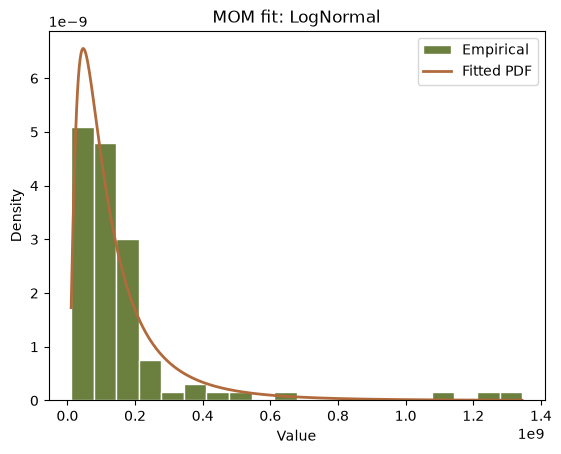

In [4]:
mom = bf.Distribution.fit("LogNormal", data, method="mom")
mom_m = mom.moments()

print(f"MOM fit: mean={mom_m['mean']:.2f}, sd={mom_m['sd']:.2f}")
print(f"  parameters (log10 space): mu={mom.params[0]:.4f}, sigma={mom.params[1]:.4f}")
plot_empirical_vs_model(data, mom, title="MOM fit: LogNormal")

## Maximum Likelihood Estimation (MLE)

MLE finds the parameter values that make the observed data most probable under the
assumed model. Given independent observations $x_1, \ldots, x_n$ with PDF
$f(x \mid \boldsymbol{\theta})$, the likelihood is

$$
L(\boldsymbol{\theta} \mid \mathbf{x}) = \prod_{i=1}^{n} f(x_i \mid \boldsymbol{\theta})
$$

and, because products are numerically unstable, optimization is performed on the
log-likelihood:

$$
\ell(\boldsymbol{\theta}) = \sum_{i=1}^{n} \log f(x_i \mid \boldsymbol{\theta}), \qquad
\hat{\boldsymbol{\theta}}_{\text{MLE}} = \underset{\boldsymbol{\theta}}{\text{argmax}} \; \ell(\boldsymbol{\theta})
$$

For some families (Normal, Exponential) the MLE has a closed form; for most
families used in hydrology it is found numerically, with initial values derived
from L-moment estimates. MLE is asymptotically efficient and unbiased, and its
log-likelihood feeds directly into AIC and BIC below. It can be biased for small
samples and requires the full probability model.

The upstream prints `Mean` (real space) and `Sigma` (the $\log_{10}$-space scale
parameter); we print the same two quantities.

In [5]:
mle = bf.Distribution.fit("LogNormal", data, method="mle")
mle_m = mle.moments()

print(f"MLE fit: mean={mle_m['mean']:.2f}, sigma(log10)={mle.params[1]:.2f}")

MLE fit: mean=149606124.89, sigma(log10)=0.38


## L-moments

L-moments are linear combinations of order statistics that provide robust
alternatives to conventional moments [1]. They are especially valuable for small
samples ($n < 50$), data with outliers, and extreme value analysis. They are
defined through probability-weighted moments (PWMs),

$$
\beta_r = E\left[X \cdot F(X)^r\right], \quad r = 0, 1, 2, \ldots
$$

with the first four L-moments

$$
\lambda_1 = \beta_0, \quad
\lambda_2 = 2\beta_1 - \beta_0, \quad
\lambda_3 = 6\beta_2 - 6\beta_1 + \beta_0, \quad
\lambda_4 = 20\beta_3 - 30\beta_2 + 12\beta_1 - \beta_0
$$

and the dimensionless ratios $\tau = \lambda_2 / \lambda_1$ (L-CV),
$\tau_3 = \lambda_3 / \lambda_2$ (L-skewness), and
$\tau_4 = \lambda_4 / \lambda_2$ (L-kurtosis). Unlike conventional skewness and
kurtosis, the ratios are bounded, which makes them stable and interpretable.
Because L-moments use only linear combinations of order statistics, a single
extreme observation cannot dominate them, and they stay nearly unbiased even for
samples as small as $n = 10$. For hydrological records of 30 to 60 annual values,
that robustness matters.

In [6]:
lm = bf.Distribution.fit("LogNormal", data, method="lmom")
lm_m = lm.moments()

print(f"L-moments fit: mean={lm_m['mean']:.2f}, sigma(log10)={lm.params[1]:.2f}")

L-moments fit: mean=147689495.62, sigma(log10)=0.37


## Comparing the three fits

The three estimation methods land on nearly the same parameters for this sample,
so the fitted PDFs almost coincide.

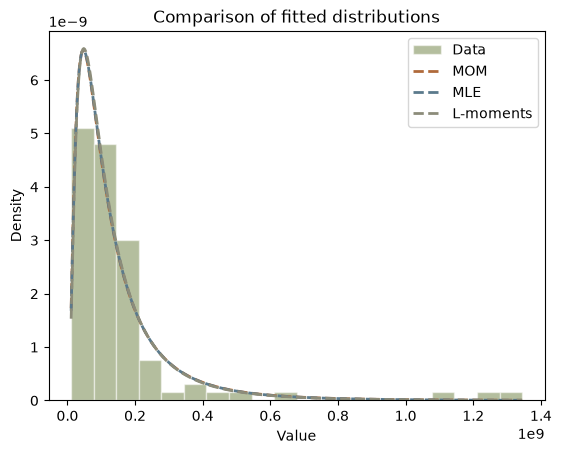

In [7]:
x = np.linspace(min(data), max(data), 500)

plt.hist(data, bins=20, density=True, color="#6b7f3f", edgecolor="white",
         alpha=0.5, label="Data")
plt.plot(x, [mom.pdf(xi) for xi in x], "--", color="#b06a3b", linewidth=2, label="MOM")
plt.plot(x, [mle.pdf(xi) for xi in x], "--", color="#5b7a8c", linewidth=2, label="MLE")
plt.plot(x, [lm.pdf(xi) for xi in x], "--", color="#8c8c7a", linewidth=2, label="L-moments")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Comparison of fitted distributions")
plt.legend()
plt.show()

## Goodness-of-fit diagnostics

We compare the models with the log-likelihood and the information criteria AIC [2]
and BIC [3]. A larger (less negative) log-likelihood and smaller AIC/BIC reflect a
better fit. The upstream notebook calls the C# `GoodnessOfFit` static class; those
metrics are two-line formulas over the log-likelihood, so this port computes them
inline. With $k$ parameters and $n$ observations:

$$
\mathrm{AIC} = 2k - 2\log L, \qquad
\mathrm{BIC} = k \ln(n) - 2\log L
$$

RMSE (smaller is better) compares the sorted observations to the fitted quantiles
at the Weibull plotting positions. One quirk of the C# implementation, reproduced
here so the numbers match the upstream table: it drops the $k$ largest observations
from the sum and divides by $n - k$.

In [8]:
k = 2  # LogNormal has two parameters
n = len(data)
sorted_data = np.sort(data)
pp = np.array(bf.plotting_positions(n))  # Weibull: i / (n + 1)


def rmse(dist):
    modeled = np.array([dist.quantile(p) for p in pp])
    m = n - k  # C# GoodnessOfFit.RMSE drops the k largest values and divides by n - k
    return np.sqrt(np.sum((modeled[:m] - sorted_data[:m]) ** 2) / m)


fits = {"LogNormal (MOM)": mom, "LogNormal (MLE)": mle, "LogNormal (L-moments)": lm}
rows = []
for name, d in fits.items():
    ll = d.log_likelihood(data)
    rows.append({
        "Distribution": name,
        "Log-Likelihood": ll,
        "AIC": 2 * k - 2 * ll,
        "BIC": k * np.log(n) - 2 * ll,
        "RMSE": rmse(d),
    })
results = pd.DataFrame(rows)
results

,Distribution,Log-Likelihood,AIC,BIC,RMSE
0,LogNormal (MOM),-1972.685554,3949.371109,3954.581449,5.995955e+07
1,LogNormal (MLE),-1972.683043,3949.366086,3954.576426,6.041398e+07
2,LogNormal (L-moments),-1972.712513,3949.425026,3954.635366,6.193926e+07


## Empirical vs fitted CDFs

Comparing the fitted CDFs to the empirical CDF gives a visual check of fit.
The empirical CDF assigns each sorted observation $x_i$ the fraction of values
less than or equal to it, $i/n$: if $\mathrm{ECDF}(x) = 0.80$, about 80% of the
observations are $\leq x$.

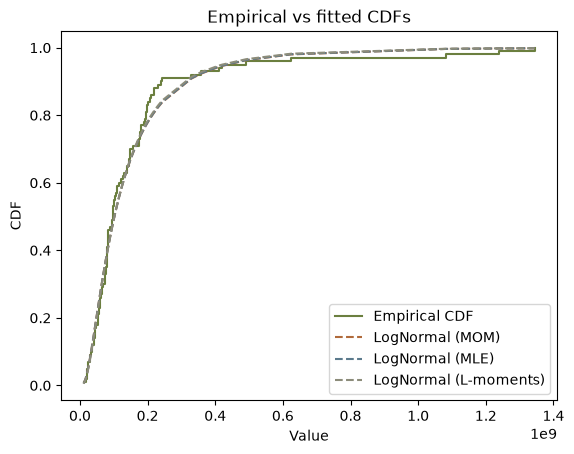

In [9]:
empirical_cdf = np.arange(1, n + 1) / n

plt.step(sorted_data, empirical_cdf, where="post", color="#6b7f3f",
         label="Empirical CDF")
plt.plot(sorted_data, [mom.cdf(v) for v in sorted_data], "--", color="#b06a3b",
         label="LogNormal (MOM)")
plt.plot(sorted_data, [mle.cdf(v) for v in sorted_data], "--", color="#5b7a8c",
         label="LogNormal (MLE)")
plt.plot(sorted_data, [lm.cdf(v) for v in sorted_data], "--", color="#8c8c7a",
         label="LogNormal (L-moments)")
plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical vs fitted CDFs")
plt.legend()
plt.show()

## Plotting positions

Plotting positions assign each ordered observation an empirical nonexceedance
probability, the basis for probability paper, hydrologic frequency plots, and
return-period calculations. The Weibull plotting position maps the $i$-th smallest
value in a sample of size $n$ to

$$
p_i = \frac{i}{n + 1}
$$

The upstream calls `PlottingPositions.Weibull(n)`; here `bf.plotting_positions(n)`
computes the same values (Weibull is the default; other conventions are available
through `method=` or `alpha=`).

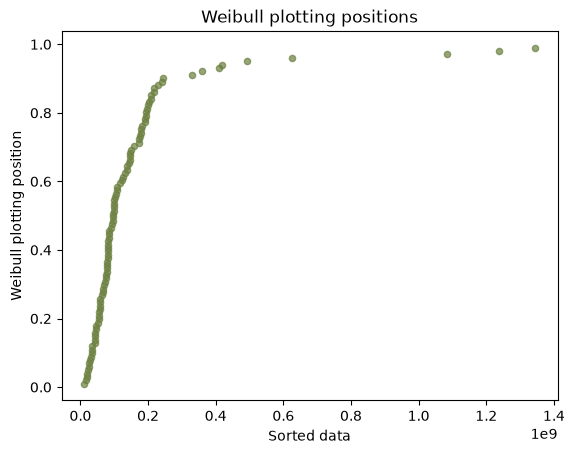

In [10]:
weibull_pp = np.array(bf.plotting_positions(n))

plt.scatter(sorted_data, weibull_pp, s=20, color="#6b7f3f", alpha=0.7)
plt.xlabel("Sorted data")
plt.ylabel("Weibull plotting position")
plt.title("Weibull plotting positions")
plt.show()

## Ranking many families at once

Beyond comparing estimation methods for one family, `bf.fit_distributions` fits 14
candidate families by MLE and reports AIC, BIC, and RMSE for each. On this sample
the LogNormal fits rank near the top, as they should for LogNormal data; two
flexible three-parameter families edge it out by a point of AIC, a normal outcome
for a single 100-value sample. Rows with `converged` False are candidates whose
MLE failed on this sample; the MLE for the difficult families uses a stochastic
global optimizer that is not seeded (matching the C# behavior), so the borderline
GeneralizedPareto row can flip between converged and failed from run to run,
while the ranked rows above are stable. (This analysis-level RMSE follows the C# convention of
using the DataFrame's Hirsch-Stedinger plotting positions, so it is not comparable
to the Weibull-based RMSE computed above.)

In [11]:
ranking = pd.DataFrame(bf.fit_distributions(data))
ranking.sort_values("aic").reset_index(drop=True)

,distribution,aic,bic,rmse,converged
0,GeneralizedLogistic,3947.264242,3955.079752,7.840581e+07,True
1,GeneralizedExtremeValue,3948.682379,3956.497889,7.944416e+07,True
2,LogNormal,3949.366075,3954.576416,1.033730e+08,True
3,LnNormal,3949.366076,3954.576416,1.033749e+08,True
4,LogPearsonTypeIII,3949.984021,3957.799531,8.959603e+07,True
5,PearsonTypeIII,3963.482322,3971.297832,1.112485e+08,True
6,Exponential,3965.298710,3970.509050,1.140558e+08,True
7,GammaDistribution,3976.384258,3981.594599,1.201342e+08,True
8,Weibull,3979.670906,3984.881247,1.119208e+08,True
9,Gumbel,4007.165263,4012.375604,1.428021e+08,True


## Summary

You have:

- fit a distribution by MOM, MLE, and L-moments with `Distribution.fit`,
- compared the fits with log-likelihood, AIC, BIC, and RMSE computed inline,
- checked the fits visually against the empirical CDF and Weibull plotting
  positions,
- ranked 14 candidate families at once with `fit_distributions`.

## Exercise

1. Generate synthetic data from a Weibull distribution
   (`bf.Distribution("Weibull", [scale, shape]).random(n, seed=...)`).
2. Fit Weibull parameters using MLE and L-moments.
3. Compare fit quality with AIC/BIC.

## References

[1] J. R. M. Hosking, "L-moments: Analysis and estimation of distributions using
linear combinations of order statistics," *Journal of the Royal Statistical
Society: Series B*, vol. 52, no. 1, pp. 105-124, 1990.

[2] H. Akaike, "A new look at the statistical model identification," *IEEE
Transactions on Automatic Control*, vol. 19, no. 6, pp. 716-723, 1974.

[3] G. Schwarz, "Estimating the dimension of a model," *Annals of Statistics*,
vol. 6, no. 2, pp. 461-464, 1978.

## Reproduction check

Values printed by the upstream notebook (run against the real C# library),
compared with this port. Everything here is deterministic seeded math, so the
match is exact; the upstream prints at 2 to 6 decimals, so the assertions compare
the formatted values, and the first seeded draw plus the MLE sigma parameter are
additionally asserted at full precision (the same full-precision values the R twin
asserts).

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| Sample mean / std (seed 123) | 158155878.08 / 213541263.95 | `np.mean(data)` / `np.std(data)` | exact |
| MOM fit mean / sd | 150193934.68 / 162945821.98 | `mom.moments()` | exact |
| MLE fit mean / sigma | 149606124.89 / 0.38 | `mle_m['mean']` / `mle.params[1]` | exact |
| L-moments fit mean / sigma | 147689495.62 / 0.37 | `lm_m['mean']` / `lm.params[1]` | exact |
| Log-likelihood (MOM/MLE/L-mom) | -1972.685554 / -1972.683043 / -1972.712513 | `d.log_likelihood(data)` | exact |
| AIC (MOM/MLE/L-mom) | 3949.371109 / 3949.366086 / 3949.425026 | `2k - 2 log L` | exact |
| BIC (MOM/MLE/L-mom) | 3954.581449 / 3954.576426 / 3954.635366 | `k ln(n) - 2 log L` | exact |
| RMSE (MOM/MLE/L-mom) | 5.995955e+07 / 6.041398e+07 / 6.193926e+07 | inline Weibull RMSE | exact |

The cell below fails the notebook if any value drifts.

In [12]:
# Upstream: 02_distribution_fitting.ipynb, cells 6, 8, 10, 12, and 16 outputs.
# The upstream prints rounded values, so compare at printed precision; the seeded
# quantities themselves are bit-exact (two full-precision anchors at the end).
assert f"{np.mean(data):.2f}" == "158155878.08"
assert f"{np.std(data):.2f}" == "213541263.95"
assert f"{mom_m['mean']:.2f}" == "150193934.68"
assert f"{mom_m['sd']:.2f}" == "162945821.98"
assert f"{mle_m['mean']:.2f}" == "149606124.89"
assert f"{mle.params[1]:.2f}" == "0.38"
assert f"{lm_m['mean']:.2f}" == "147689495.62"
assert f"{lm.params[1]:.2f}" == "0.37"

# Upstream: 02_distribution_fitting.ipynb, cell 16 (goodness-of-fit table).
expected = {
    "LogNormal (MOM)": ("-1972.685554", "3949.371109", "3954.581449", "5.995955e+07"),
    "LogNormal (MLE)": ("-1972.683043", "3949.366086", "3954.576426", "6.041398e+07"),
    "LogNormal (L-moments)": ("-1972.712513", "3949.425026", "3954.635366", "6.193926e+07"),
}
for _, row in results.iterrows():
    ll, aic, bic, rm = expected[row["Distribution"]]
    assert f"{row['Log-Likelihood']:.6f}" == ll
    assert f"{row['AIC']:.6f}" == aic
    assert f"{row['BIC']:.6f}" == bic
    assert f"{row['RMSE']:.6e}" == rm

# Full-precision anchors, identical across Python, R, and the C# library.
assert data[0] == 180774075.803667
assert mle.params[1] == 0.3810574327738998
print("All reproduction checks passed.")

All reproduction checks passed.
